In [ ]:
import yfinance as yf
from datetime import datetime

# Get the stock quote for Apple using yfinance
df = yf.download('GOOG', start='2014-10-29', end=datetime.now())

# Display the data
print(df)

[*********************100%***********************]  1 of 1 completed

Price                       Adj Close       Close        High         Low  \
Ticker                           GOOG        GOOG        GOOG        GOOG   
Date                                                                        
2014-10-29 00:00:00+00:00   27.324194   27.391296   27.633633   27.274118   
2014-10-30 00:00:00+00:00   27.372940   27.440163   27.564322   27.101093   
2014-10-31 00:00:00+00:00   27.809168   27.877462   27.901896   27.661554   
2014-11-03 00:00:00+00:00   27.617168   27.684992   27.818624   27.585764   
2014-11-04 00:00:00+00:00   27.561954   27.629642   27.698954   27.389801   
...                               ...         ...         ...         ...   
2024-11-27 00:00:00+00:00  170.820007  170.820007  171.139999  169.669998   
2024-11-29 00:00:00+00:00  170.490005  170.490005  170.869995  168.750000   
2024-12-02 00:00:00+00:00  172.979996  172.979996  173.600006  170.270004   
2024-12-03 00:00:00+00:00  173.020004  173.020004  174.320007  172.509995   

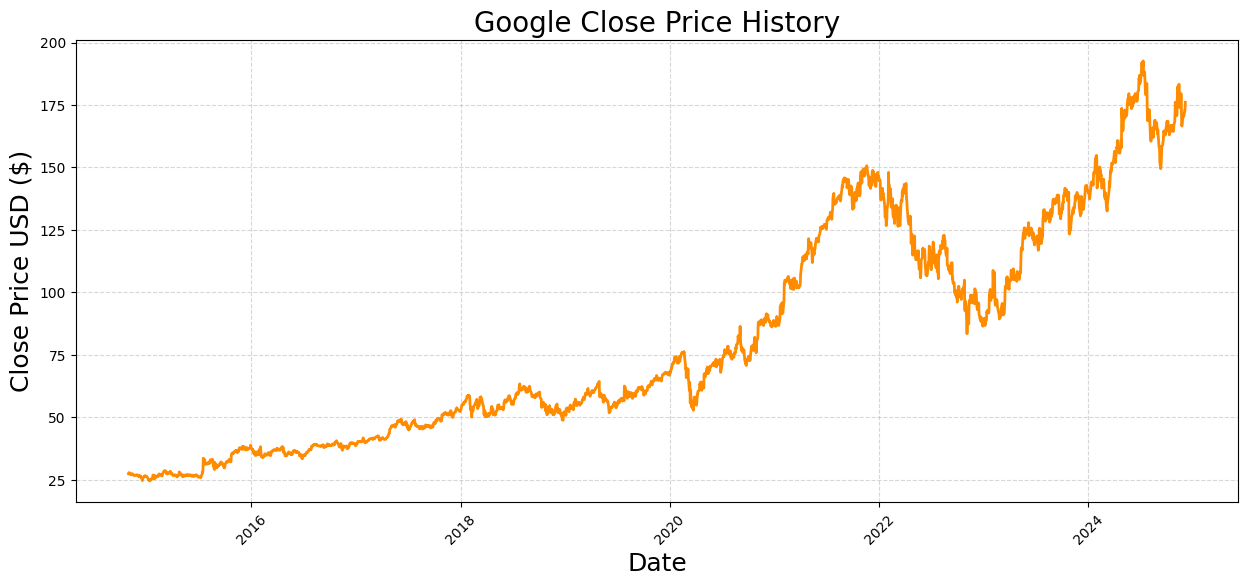

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 6))
plt.title('Google Close Price History', fontsize=20)
plt.plot(df['Close'], color='darkorange', linewidth=2)
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)

# Rotate x-axis labels for readability
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

In [ ]:
import numpy as np  # Importing numpy if not already done

# Create a new dataframe with only the 'Close' column
data = df.filter(['Close'])

# Convert the dataframe to a numpy array
dataset = data.values

# Get the number of rows to train the model on (95% of dataset)
training_data_len = int(np.ceil(len(dataset) * 0.95))

training_data_len

2415

In [ ]:
# Scale the data
from sklearn.preprocessing import MinMaxScaler

# Ensure 'Close' column exists, if not, try 'close'
if 'Close' in df.columns:
    data = df[['Close']]  # Using double brackets to ensure a DataFrame is created
else:
    data = df[['close']]  # Trying 'close' as the column name

# Convert the dataframe to a numpy array
dataset = data.values

# Get the number of rows to train the model on (95% of dataset)
training_data_len = int(np.ceil(len(dataset) * 0.95))

scaler = MinMaxScaler(feature_range=(0,1))
scaled_data = scaler.fit_transform(dataset)

scaled_data

array([[0.01684252],
       [0.01713322],
       [0.01973464],
       ...,
       [0.88292674],
       [0.88316474],
       [0.90142764]])

In [ ]:
# Create the training data set
# Create the scaled training data set
train_data = scaled_data[0:int(training_data_len), :]
# Split the data into x_train and y_train data sets
x_train = []
y_train = []

for i in range(60, len(train_data)):
    x_train.append(train_data[i-60:i, 0])
    y_train.append(train_data[i, 0])
    if i<= 61:
        print(x_train)
        print(y_train)
        print()

# Convert the x_train and y_train to numpy arrays
x_train, y_train = np.array(x_train), np.array(y_train)

# Reshape the data
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))
# x_train.shape

[array([0.01684252, 0.01713322, 0.01973464, 0.01858967, 0.0182604 ,
       0.01583102, 0.01468011, 0.01437458, 0.01629673, 0.01712728,
       0.01624333, 0.01567084, 0.01538015, 0.01303976, 0.01260075,
       0.01318214, 0.01254142, 0.01333342, 0.01385844, 0.01439535,
       0.01418475, 0.01461782, 0.01223589, 0.01222106, 0.01150026,
       0.01327706, 0.00970269, 0.0102129 , 0.01210834, 0.00994   ,
       0.01061631, 0.00774495, 0.00630334, 0.00084242, 0.00366039,
       0.00550245, 0.00705975, 0.00958701, 0.01128372, 0.01074386,
       0.01230412, 0.01120659, 0.01123329, 0.01004085, 0.00956921,
       0.00632411, 0.00279127, 0.00253617, 0.00300484, 0.0010738 ,
       0.        , 0.00107676, 0.00246795, 0.00274084, 0.00460663,
       0.00425661, 0.00756105, 0.0124109 , 0.01406015, 0.01265413])]
[0.007736054796774916]

[array([0.01684252, 0.01713322, 0.01973464, 0.01858967, 0.0182604 ,
       0.01583102, 0.01468011, 0.01437458, 0.01629673, 0.01712728,
       0.01624333, 0.01567084, 0.0

In [ ]:
from keras.models import Sequential
from keras.layers import Dense, LSTM

# Build the LSTM model
model = Sequential()
model.add(LSTM(128, return_sequences=True, input_shape= (x_train.shape[1], 1)))
model.add(LSTM(64, return_sequences=False))
model.add(Dense(25))
model.add(Dense(1))

# Compile the model
model.compile(optimizer='adam', loss='mean_squared_error')

# Train the model
model.fit(x_train, y_train, batch_size=1, epochs=1)

/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


2355/2355 ━━━━━━━━━━━━━━━━━━━━ 130s 54ms/step - loss: 0.0017


In [ ]:
# Create the testing data set
# Create a new array containing scaled values from index 1543 to 2002
test_data = scaled_data[training_data_len - 60: , :]
# Create the data sets x_test and y_test
x_test = []
y_test = dataset[training_data_len:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

# Convert the data to a numpy array
x_test = np.array(x_test)

# Reshape the data
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1 ))

# Get the models predicted price values
predictions = model.predict(x_test)
predictions = scaler.inverse_transform(predictions)

# Get the root mean squared error (RMSE)
rmse = np.sqrt(np.mean(((predictions - y_test) ** 2)))
rmse

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 310ms/step


6.192341847577113

<ipython-input-8-0cdd5e68a3a9>:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  valid['Predictions'] = predictions


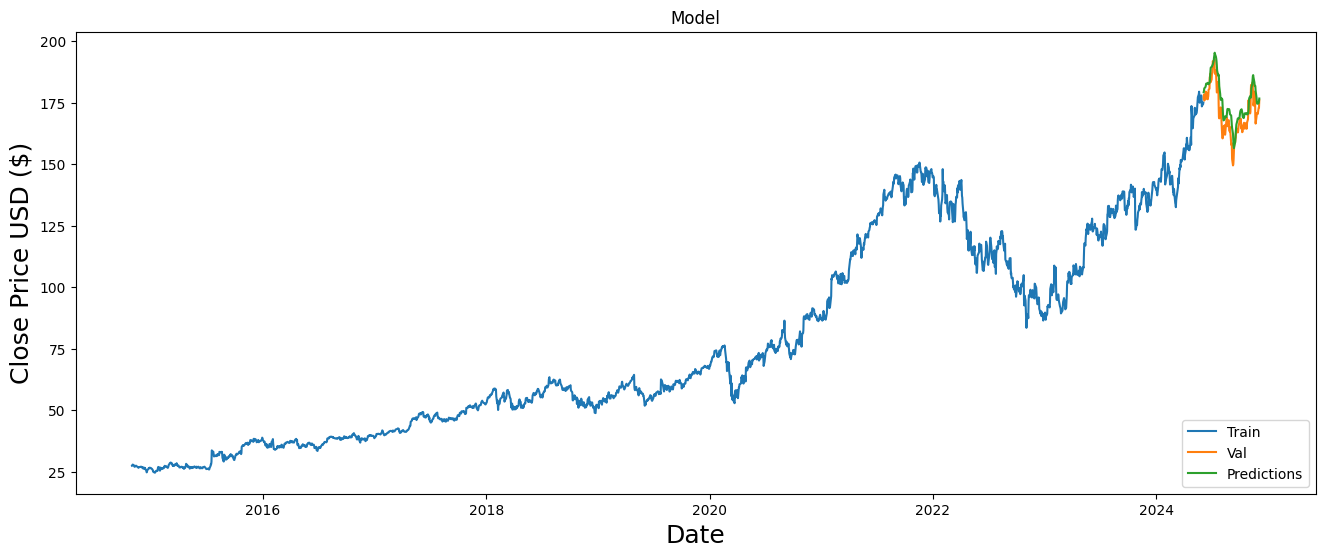

In [ ]:
# Plot the data
train = data[:training_data_len]
valid = data[training_data_len:]
valid['Predictions'] = predictions
# Visualize the data
plt.figure(figsize=(16,6))
plt.title('Model')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price USD ($)', fontsize=18)
plt.plot(train['Close'])
plt.plot(valid[['Close', 'Predictions']])
plt.legend(['Train', 'Val', 'Predictions'], loc='lower right')
plt.show()

In [ ]:
# Show the valid and predicted prices
valid

Price,Close,Predictions
Ticker,GOOG,
Date,,
2024-06-05 00:00:00+00:00,177.070007,179.318451
2024-06-06 00:00:00+00:00,178.350006,179.879669
2024-06-07 00:00:00+00:00,175.949997,180.901413
2024-06-10 00:00:00+00:00,176.630005,181.292130
2024-06-11 00:00:00+00:00,178.190002,181.531464
...,...,...
2024-11-27 00:00:00+00:00,170.820007,174.658188
2024-11-29 00:00:00+00:00,170.490005,174.661362


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, predictions)
mse = mean_squared_error(y_test, predictions)
rmse = np.sqrt(mse)  # RMSE is the square root of MSE

# Display the metrics
print("Evaluation Metrics:")
print(f"Mean Absolute Error (MAE): {mae}")
print(f"Mean Squared Error (MSE): {mse}")
print(f"Root Mean Squared Error (RMSE): {rmse}")

Evaluation Metrics:
Mean Absolute Error (MAE): 5.118116844357468
Mean Squared Error (MSE): 38.34509755725474
Root Mean Squared Error (RMSE): 6.192341847577113
